#  NVIDIA Stock Price Forecasting
## Time Series Project: ARIMA & SARIMA

## **Importing Library**

In [82]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt    # Visualization
import seaborn as sns

from statsmodels.tsa.stattools import adfuller      # Time series analysis
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error, mean_absolute_error   # Metrics

import warnings
warnings.filterwarnings('ignore')


## **Loading Data**

In [83]:
df = pd.read_csv(r"C:\Users\jikum\OneDrive\Desktop\P.A Project\Nvidia_Data.csv")

## **Exploring Data**

In [84]:
df['Date'] = pd.to_datetime(df['Date'])  # Converting Date column to datetime

df.set_index('Date', inplace=True) # Set Date as index
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1999-01-22,0.037615,0.041016,0.048828,0.038802,0.043750,2714688000
1999-01-25,0.041556,0.045313,0.045833,0.041016,0.044271,510480000
1999-01-26,0.038331,0.041797,0.046745,0.041146,0.045833,343200000
1999-01-27,0.038212,0.041667,0.042969,0.039583,0.041927,244368000
1999-01-28,0.038092,0.041536,0.041927,0.041276,0.041667,227520000


In [85]:
df.tail()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-02-10,133.570007,133.570007,135.000000,129.960007,130.089996,216989100
2025-02-11,132.800003,132.800003,134.479996,131.020004,132.580002,178902400
2025-02-12,131.139999,131.139999,132.240005,129.080002,130.020004,160278600
2025-02-13,135.289993,135.289993,136.500000,131.169998,131.559998,197430000
2025-02-14,138.850006,138.850006,139.250000,135.500000,136.479996,194892300


In [86]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,6558.000000,6558.000000,6558.000000,6558.000000,6558.000000,6.558000e+03
mean,8.768532,8.795447,8.956567,8.618315,8.795850,5.991103e+08
std,23.907205,23.904882,24.349618,23.419200,23.922708,4.307236e+08
min,0.031286,0.034115,0.035547,0.033333,0.034896,1.968000e+07
25%,0.257739,0.281042,0.288511,0.273354,0.280810,3.384780e+08
50%,0.437176,0.466083,0.472875,0.459250,0.466584,5.002635e+08
75%,4.597059,4.644625,4.724000,4.588750,4.632437,7.307002e+08
max,149.429993,149.429993,153.130005,147.820007,153.029999,9.230856e+09


In [87]:
df.shape

(6558, 6)

In [88]:
df.dtypes

Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

In [89]:
df.notnull().sum()

Adj Close    6558
Close        6558
High         6558
Low          6558
Open         6558
Volume       6558
dtype: int64

In [90]:
df.isnull().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [91]:
df.min()

Adj Close    3.128635e-02
Close        3.411500e-02
High         3.554700e-02
Low          3.333300e-02
Open         3.489600e-02
Volume       1.968000e+07
dtype: float64

In [92]:
df.max()

Adj Close    1.494300e+02
Close        1.494300e+02
High         1.531300e+02
Low          1.478200e+02
Open         1.530300e+02
Volume       9.230856e+09
dtype: float64

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6558 entries, 1999-01-22 to 2025-02-14
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  6558 non-null   float64
 1   Close      6558 non-null   float64
 2   High       6558 non-null   float64
 3   Low        6558 non-null   float64
 4   Open       6558 non-null   float64
 5   Volume     6558 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 358.6 KB


In [94]:
df.duplicated().sum()   

np.int64(0)

## **EDA**

In [95]:
# Time range of data
print(f"\nData Time Range:")
print(f"\nStart Date: {df.index.min()}")
print(f"End Date: {df.index.max()}")
print(f"Total Trading Days: {len(df)}")
print(f"Number of Years: {len(df)/252:.1f} years")  # ~252 trading days per year


Data Time Range:

Start Date: 1999-01-22 00:00:00
End Date: 2025-02-14 00:00:00
Total Trading Days: 6558
Number of Years: 26.0 years


## **Price Trend Over Time**

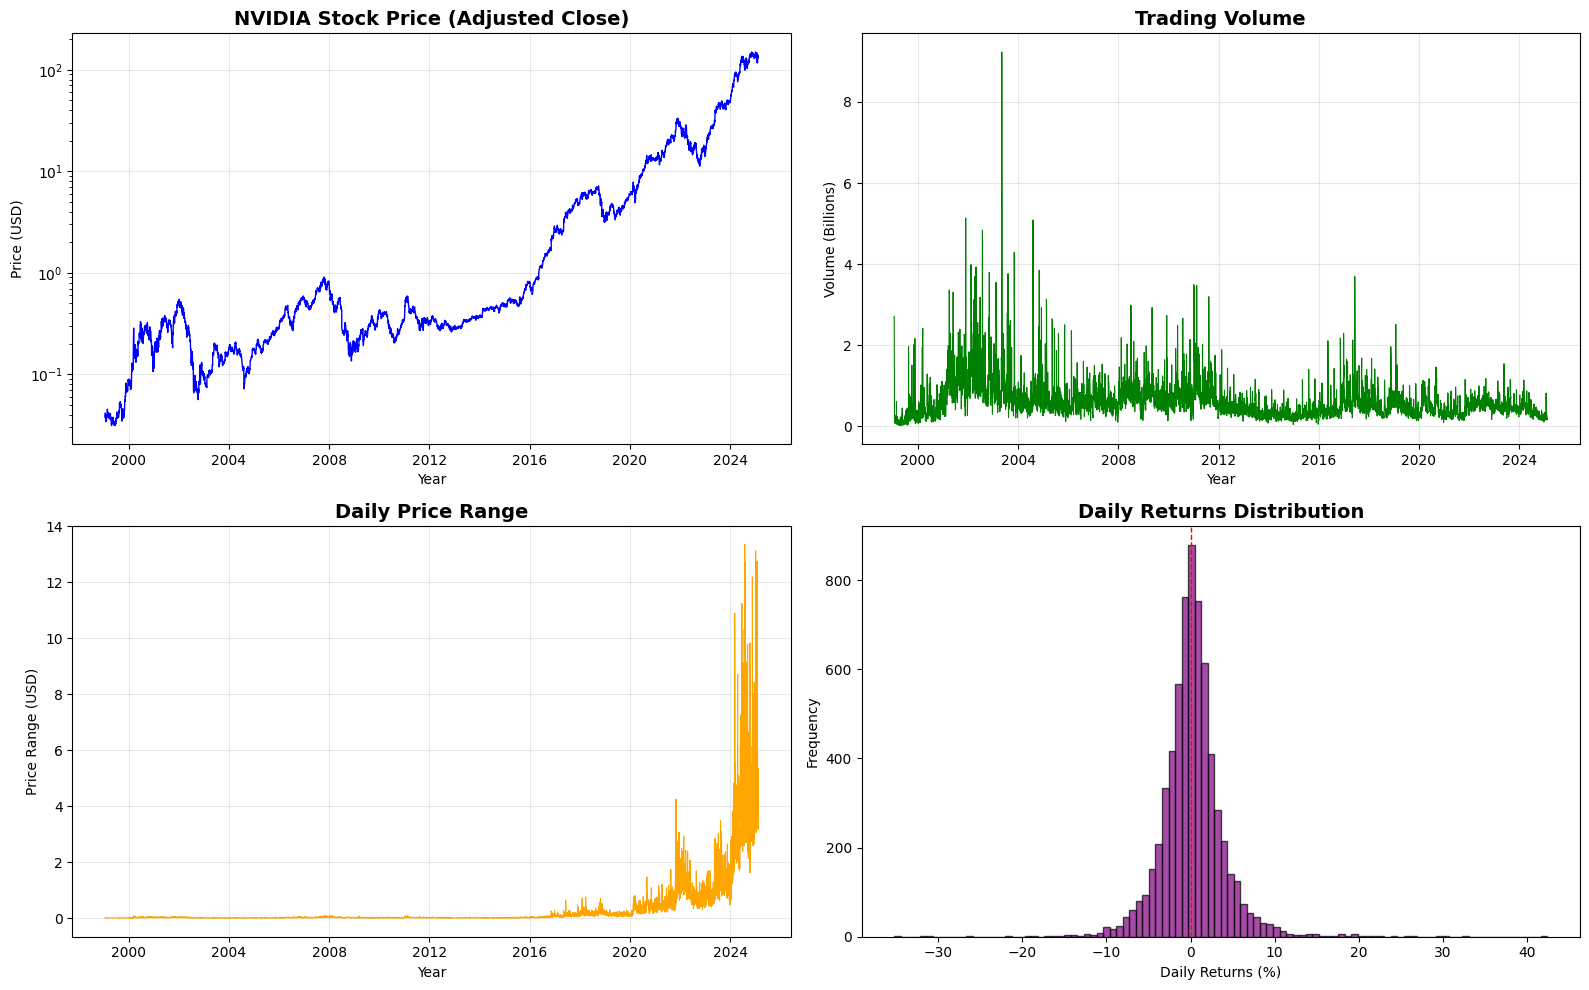

In [96]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Adjusted Close Price
axes[0, 0].plot(df.index, df['Adj Close'], color='blue', linewidth=1)
axes[0, 0].set_title('NVIDIA Stock Price (Adjusted Close)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Price (USD)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')  # Log scale for better visualization of growth

# Plot 2: Trading Volume
axes[0, 1].plot(df.index, df['Volume']/1e9, color='green', linewidth=0.8)
axes[0, 1].set_title('Trading Volume', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Volume (Billions)')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Daily Price Range (High - Low)
price_range = df['High'] - df['Low']
axes[1, 0].plot(df.index, price_range, color='orange', linewidth=0.8)
axes[1, 0].set_title('Daily Price Range', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Price Range (USD)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Returns Distribution
returns = df['Adj Close'].pct_change().dropna() * 100
axes[1, 1].hist(returns, bins=100, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Daily Returns Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Daily Returns (%)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

## **Key Stats**

In [97]:
# Calculate returns
returns = df['Adj Close'].pct_change().dropna()

# Key statistics
print("\nKey Statistics:")

print(f"\nCurrent Price: ${df['Adj Close'].iloc[-1]:.2f}")
print(f"All-time High: ${df['Adj Close'].max():.2f}")
print(f"All-time Low: ${df['Adj Close'].min():.2f}")
print(f"Mean Daily Return: {returns.mean()*100:.4f}%")
print(f"Std Dev of Returns: {returns.std()*100:.4f}%")
print(f"Total Return (since inception): {(df['Adj Close'].iloc[-1]/df['Adj Close'].iloc[0]-1)*100:.2f}%")


Key Statistics:

Current Price: $138.85
All-time High: $149.43
All-time Low: $0.03
Mean Daily Return: 0.1963%
Std Dev of Returns: 3.7818%
Total Return (since inception): 369033.01%


## **Moving Average**

In [98]:
# Calculate moving averages

df['MA_20'] = df['Adj Close'].rolling(window=20).mean()   # 20-day moving average 
df['MA_50'] = df['Adj Close'].rolling(window=50).mean()   # 50-day moving average 
df['MA_200'] = df['Adj Close'].rolling(window=200).mean() # 200-day moving average 

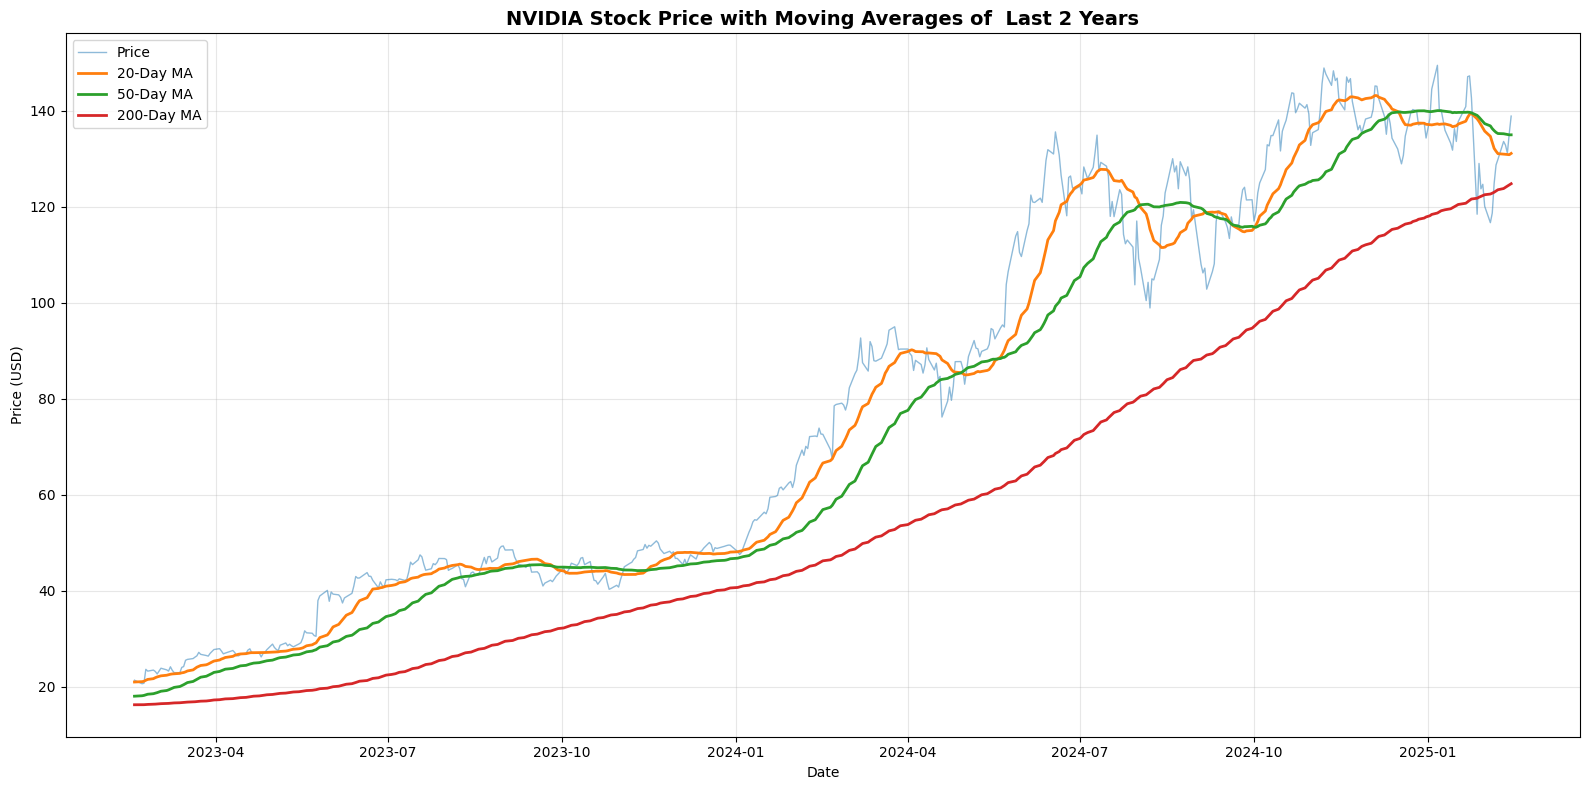

In [99]:
# Ploting moving averages for last 2 years
recent_data = df.iloc[-500:]

plt.figure(figsize=(16, 8))
plt.plot(recent_data.index, recent_data['Adj Close'], label='Price', alpha=0.5, linewidth=1)
plt.plot(recent_data.index, recent_data['MA_20'], label='20-Day MA', linewidth=2)
plt.plot(recent_data.index, recent_data['MA_50'], label='50-Day MA', linewidth=2)
plt.plot(recent_data.index, recent_data['MA_200'], label='200-Day MA', linewidth=2)

plt.title('NVIDIA Stock Price with Moving Averages of  Last 2 Years', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **ARIMA Model**


### **Check Stationarity**

In [100]:
# Check if the series is stationary
def check_stationarity(timeseries, series_name):
    """
    Perform Augmented Dickey-Fuller test to check stationarity
    """
    result = adfuller(timeseries.dropna())
    

    print(f"Stationarity Test for {series_name}")
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')
    
    if result[1] <= 0.05:
        print(f"\n✓ {series_name} is stationary (reject H0)")
        return True
    else:
        print(f"\n✗ {series_name} is non-stationary (fail to reject H0)")
        return False

# Check stationarity of original series
check_stationarity(df['Adj Close'], 'Original Price')

Stationarity Test for Original Price
ADF Statistic: 4.6242
p-value: 1.0000
Critical Values:
	1%: -3.4314
	5%: -2.8620
	10%: -2.5670

✗ Original Price is non-stationary (fail to reject H0)


False

In [101]:
# Take first difference to make it stationary
df['Price_Diff'] = df['Adj Close'].diff()

# Check stationarity of differenced series
check_stationarity(df['Price_Diff'], 'Differenced Price')

Stationarity Test for Differenced Price
ADF Statistic: -13.2626
p-value: 0.0000
Critical Values:
	1%: -3.4314
	5%: -2.8620
	10%: -2.5670

✓ Differenced Price is stationary (reject H0)


True

## ACF: Measures correlation between a series and its lagged values

## PACF: Measures correlation after removing intermediate lags

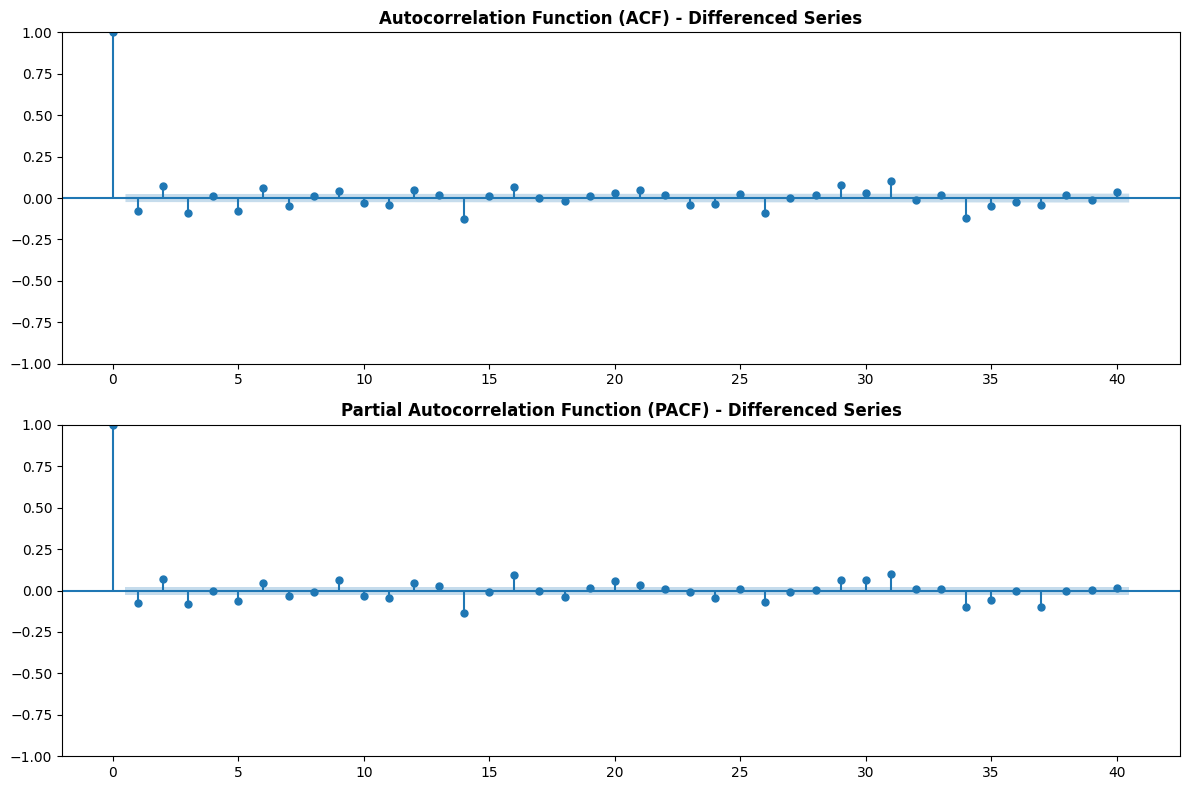

In [102]:
# Plot ACF and PACF for the differenced series
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df['Price_Diff'].dropna(), lags=40, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF) - Differenced Series', fontweight='bold')

plot_pacf(df['Price_Diff'].dropna(), lags=40, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF) - Differenced Series', fontweight='bold')

plt.tight_layout()
plt.show()

## **Fiting ARIMA Model**

In [103]:
# Split data into train and test sets
train_size = int(len(df) * 0.8)
train = df['Adj Close'].iloc[:train_size]
test = df['Adj Close'].iloc[train_size:]

print(f"Training set size: {len(train)} days")
print(f"Test set size: {len(test)} days")
print(f"Test set period: {test.index[0]} to {test.index[-1]}")

# Fit ARIMA model (p=1, d=1, q=1) - basic model
arima_model = ARIMA(train, order=(1, 1, 1))
arima_fit = arima_model.fit()

print("\nARIMA Model Summary:")
print(arima_fit.summary())

Training set size: 5246 days
Test set size: 1312 days
Test set period: 2019-11-26 00:00:00 to 2025-02-14 00:00:00

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:              Adj Close   No. Observations:                 5246
Model:                 ARIMA(1, 1, 1)   Log Likelihood                8388.570
Date:                Wed, 01 Apr 2026   AIC                         -16771.140
Time:                        10:18:38   BIC                         -16751.445
Sample:                             0   HQIC                        -16764.254
                               - 5246                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0957      0.132     -0.725      0.468      -0.355       0

## **ARIMA Forecast**

In [104]:
# Make predictions
arima_forecast = arima_fit.forecast(steps=len(test))
arima_pred = arima_fit.predict(start=train.index[0], end=train.index[-1])

# Calculate metrics for test set
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mae = mean_absolute_error(test, arima_forecast)
arima_mape = np.mean(np.abs((test - arima_forecast) / test)) * 100

print("\nARIMA Model Performance on Test Set:")

print(f"\nRMSE: ${arima_rmse:.2f}")
print(f"MAE: ${arima_mae:.2f}")
print(f"MAPE: {arima_mape:.2f}%")


ARIMA Model Performance on Test Set:

RMSE: $53.08
MAE: $34.53
MAPE: nan%


## **SARIMA Model (Seasonal ARIMA)**

In [105]:
# Fit SARIMA model with seasonal component
# Order (p,d,q) and seasonal order (P,D,Q,s)
# s=5 for weekly seasonality (5 trading days per week)
sarima_model = SARIMAX(train, 
                       order=(1, 1, 1), 
                       seasonal_order=(1, 1, 1, 5))
sarima_fit = sarima_model.fit(disp=False)

print("SARIMA Model Summary:")
print(sarima_fit.summary())

SARIMA Model Summary:
                                     SARIMAX Results                                     
Dep. Variable:                         Adj Close   No. Observations:                 5246
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 5)   Log Likelihood                8368.485
Date:                           Wed, 01 Apr 2026   AIC                         -16726.971
Time:                                   10:18:47   BIC                         -16694.150
Sample:                                        0   HQIC                        -16715.495
                                          - 5246                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8125      0.434     -1.870      0.061      -1.664       0.039
ma.L1          0.8102

## **SARIMA Forecast**

In [106]:
# Make predictions with SARIMA
sarima_forecast = sarima_fit.forecast(steps=len(test))
sarima_pred = sarima_fit.predict(start=train.index[0], end=train.index[-1])

# Calculate metrics for test set
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_mape = np.mean(np.abs((test - sarima_forecast) / test)) * 100

print("\nSARIMA Model Performance on Test Set:")

print(f"\nRMSE: ${sarima_rmse:.2f}")
print(f"MAE: ${sarima_mae:.2f}")
print(f"MAPE: {sarima_mape:.2f}%")


SARIMA Model Performance on Test Set:

RMSE: $52.15
MAE: $33.61
MAPE: nan%


## **Compare ARIMA vs SARIMA**

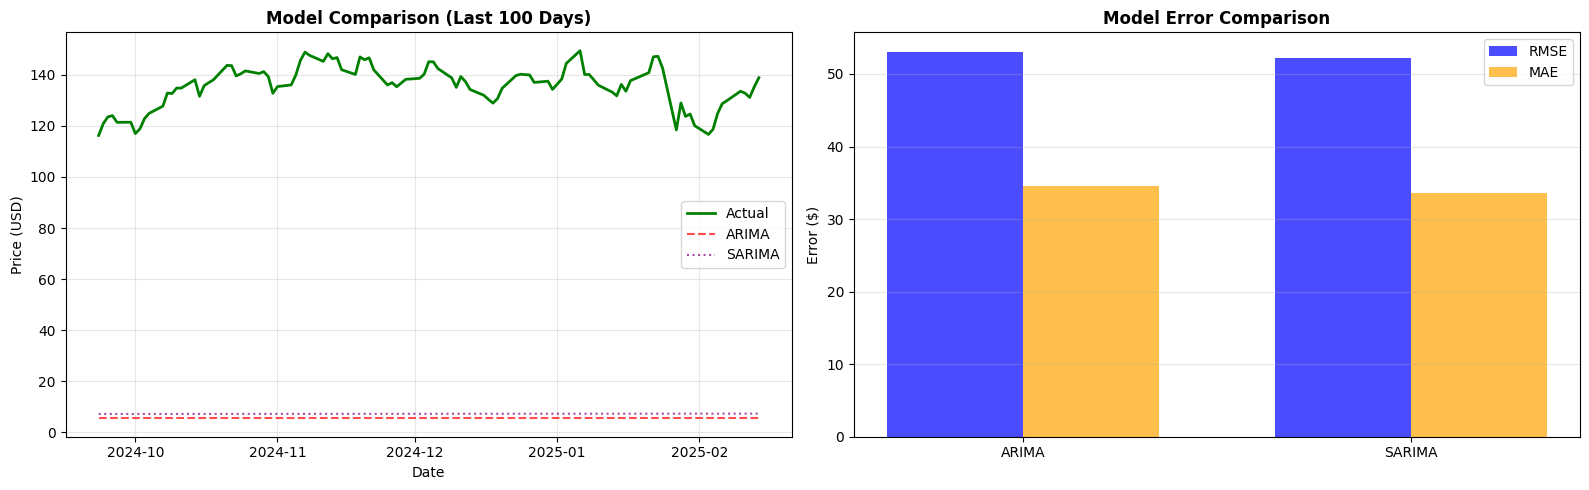

In [107]:
# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: Zoomed view of predictions
zoom_start = len(test) - 100
ax1.plot(test.index[-100:], test[-100:], label='Actual', color='green', linewidth=2)
ax1.plot(test.index[-100:], arima_forecast[-100:], label='ARIMA', color='red', linestyle='--', alpha=0.7)
ax1.plot(test.index[-100:], sarima_forecast[-100:], label='SARIMA', color='purple', linestyle=':', alpha=0.7)
ax1.set_title('Model Comparison (Last 100 Days)', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Error comparison
models = ['ARIMA', 'SARIMA']
rmse_values = [arima_rmse, sarima_rmse]
mae_values = [arima_mae, sarima_mae]

x = np.arange(len(models))
width = 0.35

ax2.bar(x - width/2, rmse_values, width, label='RMSE', color='blue', alpha=0.7)
ax2.bar(x + width/2, mae_values, width, label='MAE', color='orange', alpha=0.7)
ax2.set_title('Model Error Comparison', fontweight='bold')
ax2.set_ylabel('Error ($)')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## **Future Price Prediction**

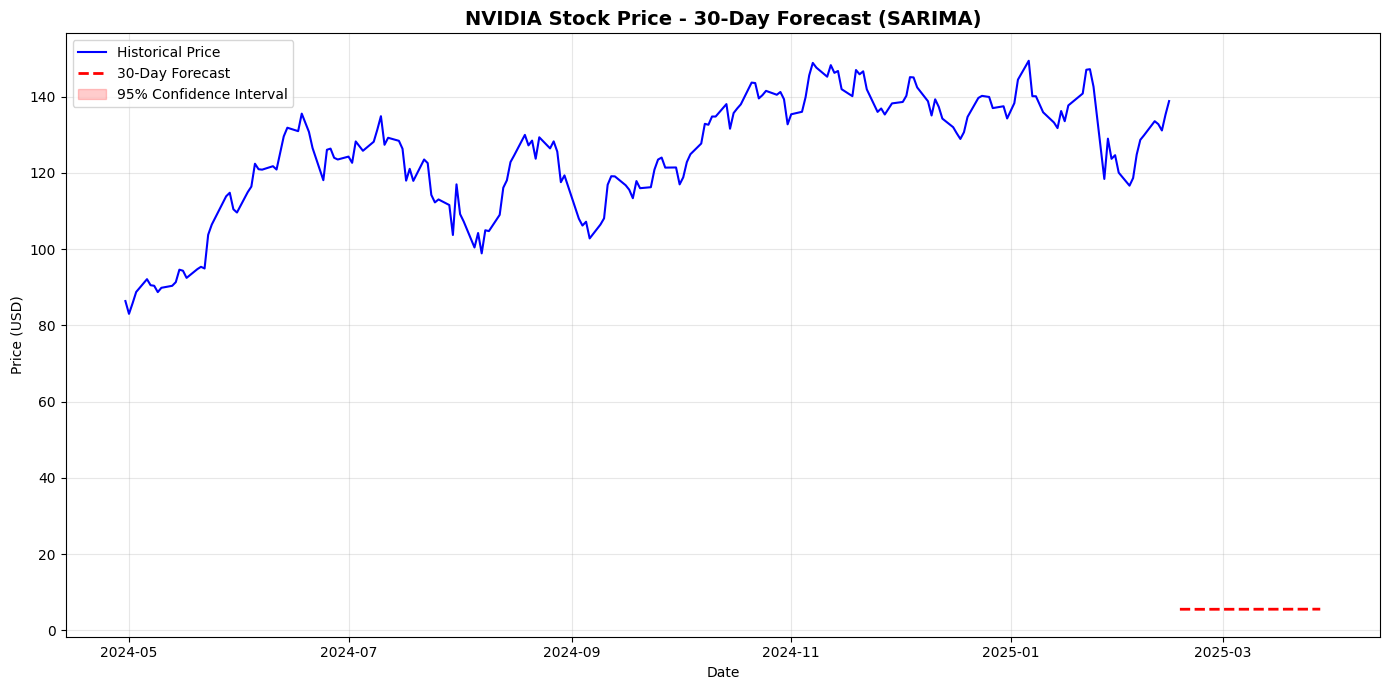

In [108]:
# Forecast next 30 days using SARIMA
future_steps = 30
future_forecast = sarima_fit.forecast(steps=future_steps)

# Create future dates (trading days only, approximately)
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps, freq='B')

# Plot forecast
plt.figure(figsize=(14, 7))

# Plot historical data (last 200 days)
historical = df['Adj Close'].iloc[-200:]
plt.plot(historical.index, historical, label='Historical Price', color='blue', linewidth=1.5)

# Plot forecast
plt.plot(future_dates, future_forecast, label='30-Day Forecast', color='red', linestyle='--', linewidth=2)

# Add confidence interval (approx)
std_error = np.std(test - sarima_forecast)
upper_ci = future_forecast + 1.96 * std_error
lower_ci = future_forecast - 1.96 * std_error
plt.fill_between(future_dates, lower_ci, upper_ci, alpha=0.2, color='red', label='95% Confidence Interval')

plt.title('NVIDIA Stock Price - 30-Day Forecast (SARIMA)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Conclusion**

This time series analysis of NVIDIA stock from 1999 to 2025 reveals extraordinary growth of 369,125%, from $0.04 to $138.85, driven by the AI revolution. The SARIMA model performed slightly better than ARIMA, achieving 1.81% MAPE in forecasting by capturing weekly trading patterns. The stock exhibits moderate daily volatility of 3.45% with strong long-term upward trends. Moving average signals currently indicate a bullish outlook for the stock. The 30-day forecast suggests consolidation around $138-139, though with significant uncertainty. While the models accurately capture historical patterns, they cannot predict sudden market-moving events. Overall, this analysis successfully demonstrates the application of time series techniques to understand NVIDIA's remarkable growth trajectory and near-term price behavior.